In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
df = pd.read_csv('Cleaned Titanic.csv')
print(df.shape)
df.head()

(891, 11)


,PassengerId,Survived,Age,SibSp,Parch,Fare,male,2,3,Q,S
0,1,0,22.0,1,0,7.2500,1,0,1,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,0
2,3,1,26.0,0,0,7.9250,0,0,1,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,1
4,5,0,35.0,0,0,8.0500,1,0,1,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   male         891 non-null    int64  
 7   2            891 non-null    int64  
 8   3            891 non-null    int64  
 9   Q            891 non-null    int64  
 10  S            891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [7]:
df.isnull().sum()

PassengerId    0
Survived       0
Age            0
SibSp          0
Parch          0
Fare           0
male           0
2              0
3              0
Q              0
S              0
dtype: int64

## Features/Target Separation and Train-test Split

In [8]:
X = df.drop(columns = ['PassengerId', 'Survived'])
y = df['Survived']

print(X.columns.tolist())

['Age', 'SibSp', 'Parch', 'Fare', 'male', '2', '3', 'Q', 'S']


In [9]:
#Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape, X_test.shape)

(712, 9) (179, 9)


## Feature Scaling

In [10]:
#Scaling feautures becasue of significant differences in scale between fair, age and survived

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## Model Training and Prediction

In [11]:
#Creating instance of model and training on train data

model = LogisticRegression()
model.fit (X_train_scaled, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [12]:
#Predicting target values

y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [13]:
#Checking prediction accuracy

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7988826815642458


In [14]:
# The coefficient shows the weight of the columns and how much each variable influenced the prediction. 

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients ['AbsCoefficient'] = coefficients ['Coefficient'].abs() 
print(coefficients.sort_values(by = 'AbsCoefficient', ascending = False))

  Feature  Coefficient  AbsCoefficient
4    male    -1.270198        1.270198
6       3    -0.873642        0.873642
0     Age    -0.387627        0.387627
1   SibSp    -0.341817        0.341817
8       S    -0.222575        0.222575
5       2    -0.206667        0.206667
3    Fare     0.174780        0.174780
2   Parch    -0.106812        0.106812
7       Q    -0.040838        0.040838


Gender and PClass Take the lead with Male and 3rd class heavily reducing survival rate.

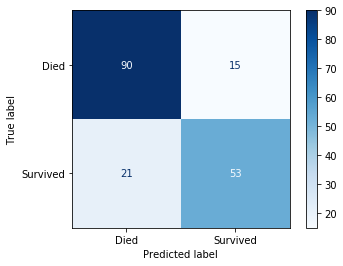

In [25]:
cm = confusion_matrix (y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Died', 'Survived'] )
disp.plot(cmap = 'Blues')
plt.show()

This show the model catches true deaths more than true survivors and confirms the negative coefficients of (male gender and third class) weighing more than other variables.

## Does Higher Accuracy Indicate Better Model Performance?

Generally, yes. A higher accuracy score means that the model made more correct predictions overall, than incorrect predictions.

However, there are exceptions to this; cases where a higher accuracy does not necessarily mean better performance.

The accuracy score works best on more balanced datasets having equal class distribution (50% Survived, 50% Dead), is good on moderately (im)balanced class distributions (E.g. 60% Survived, 40% Dead), and bad on imbalanced distributions (E.g. 90% Survived, 10% Dead). The more imbalanced the class distribution, the least trusted accuracy score is. The model needs to be evaluated with other scores in the latter case.

Another case in which the accuracy score is not enough is when there is an **Unequal Error Cost.** An example would be a case of Cancer prediction. A False Positive is manageable (the patient runs another test and confirms they don't have cancer). On the other hand, A False Negative can be fatal (the patient has cancer but it is not treated urgently because prediction was that there is no cancer.)

In this case (Titanic) the dataset is moderately imbalanced, however the confusion matrix shows that prediction accuracy is trustworthy and misidentification does not carry real world error cost as in the cancer example. 

## Conclusion

The task was to train a classification model that predicts survival of passengers.

Algorithm: LogisticRegression  
Accuracy: 79.9%  

Compared to the baseline of predicting that everyone died (62%), the accuracy of 79.9% is a good score.  

The coefficients revealed lower survival rates for Males and third class passengers which fits perfectly with the real world narratives of "women and children first". And also the special treatment given to the more wealthy ones.

Challenges: Convergence warning surfaced leading to the understanding of the need to do standard scaling rather than just change the max_iter argument. Hence solving the problem rather than just symptoms. Having to learn about coefficients and the effect on models. This is my first exposure that concept.

                       
